# GeoPandas AI - Flood Analysis Sample

In this Jupyter Notebook, we propose to perform geospatial analysis of a dataset using GeoPandas AI.

# Initialisation of GeoPandas AI

GeoPandas AI relies on an external AI service, which you can configure through LiteLLM.

In [1]:
from litellm import completion
import os

import geopandas as gpd
import geopandasai as gai
from folium import Map
from geopandasai import update_geopandasai_config
from matplotlib.figure import Figure

update_geopandasai_config(
    lite_llm_config={
        "model": "vertex_ai/meta/llama3-70b-instruct-maas", # You can change this according to litellm documentation.
        "temperature": 0,  # To be albe to replicate this tutorial, not recommended for real usage
        "vertex_credentials": os.environ.get("VERTEX_CREDENTIALS"),
        "vertex_project": os.environ.get("VERTEX_PROJECT"),
        "vertex_location": os.environ.get("VERTEX_LOCATION"),
    }
)



# Data analysis

We will now load the different data files as gdf, convert them to GeoDataFrameAI, to be able to interact with them in Natural Language.

A temperature of 0 is provided to increase the reproductibility of this notebook. However, this is not enough to guarentee that the LLM will produce 100% deterministic results. Therefore, resetting the cache may lead to different outputs.

In [2]:
gai.reset_cache()

In [3]:
floodedAreas_gdf = gpd.read_file("./Data/Shps/boiseFlood200yr_v4.shp") # gai.read_file(...), would also work and directly instantiate a GeoDataFrameAI
highways_gdf = gpd.read_file("./Data/Shps/primaryHighways.gpkg")
facilities_gdf = gpd.read_file('./Data/Shps/schoolsHospitalsPoliceFire.gpkg')

In [4]:
floodedAreas = gai.GeoDataFrameAI(floodedAreas_gdf)
highways = gai.GeoDataFrameAI(highways_gdf, description="This dataset contains information about roads.")
facilities = gai.GeoDataFrameAI(facilities_gdf)

/home/gaspard/Documents/Dev/CoDE/geopandas-ai/.venv/lib/python3.12/site-packages/geopandas/geodataframe.py:223: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  super().__setattr__(attr, val)


In [18]:
floodedAreas.chat("What are the the bounds of the flooded areas.")


,geometry
0,"POLYGON ((-116.51642 43.6624, -116.2989 43.662..."


<Figure size 1000x1000 with 1 Axes>

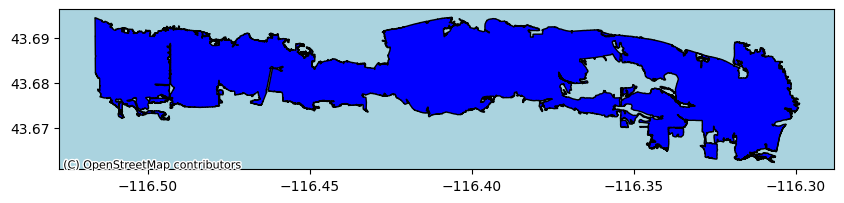

In [6]:
floodedAreas.chat("Plot the flooded areas.")

In [7]:
highways.chat("Plot the roads.").improve("Add a legend. Roads with the same name should have the same color.").improve(
    "Improve the legend, it does not fit in its box. Make it scrollable.")

In [8]:
facilities.chat("Find unique amenities.")

['school', 'hospital', 'fire_station']

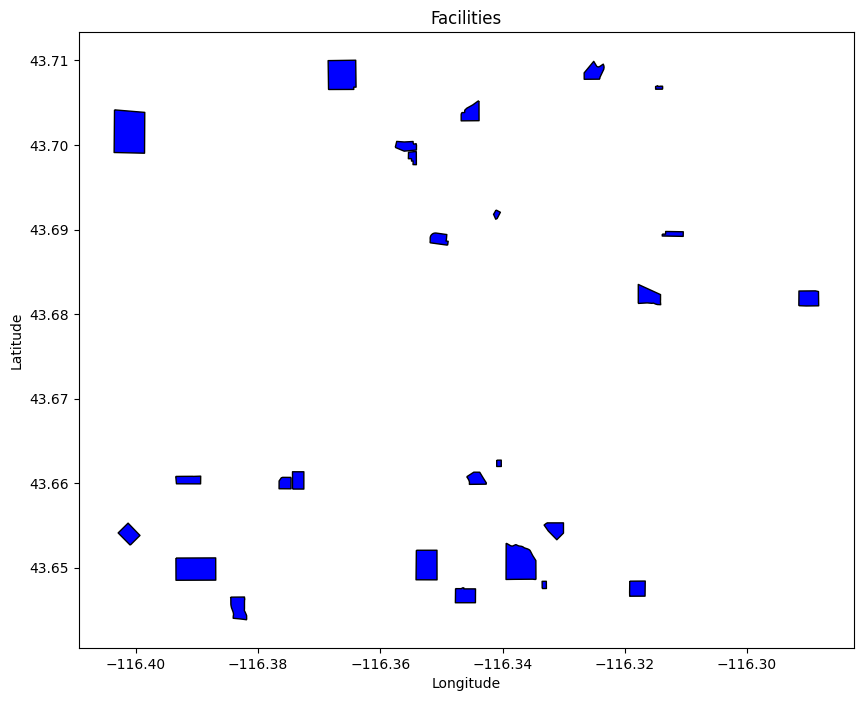

In [9]:
fig = facilities.chat("Plot the facilities.", return_type=Figure)

In [10]:
highways.chat(
    "Plot the highways the schools, and flooded areas.",
    floodedAreas,
    facilities,
    return_type=Map,
).improve("Save in map.html file")

In [11]:
floodedFacilities = facilities.chat(
    "Add a Flooded column to the facilities based on whether they are in the flooded areas",
    floodedAreas,
)


It should be noted, that when GeoPandas-AI returns a GDF or a DF, improve functions cannot yet be "chained" on the same line. If the users need to improve the GDF-AI, they need to do it in a separate expression:

In [12]:
# floodedFacilities = facilities.improve("Keep only the facilities flooded.")

In [14]:
floodedFacilities.chat("Export to the Out/floodedSchools.gpkg. Keep only the facilities flooded.", return_type=None)

,amenity,name,STAGE,ELEV,USGSID,GRIDID,QCFS,STGRATING,Comments,Area,Flooded


In [15]:
facilities.inspect()

Prompt 1: Add a Flooded column to the facilities based on whether they are in the flooded areas
Code 1:

import geopandas as gpd
import pandas as pd

def execute(df_1, df_2) -> pd.core.frame.DataFrame:
    """
    Add a Flooded column to the facilities based on whether they are in the flooded areas.

    Parameters
    ----------
    df_1 : geopandas.GeoDataFrame
        Facilities data.
    df_2 : geopandas.GeoDataFrame
        Flooded areas data.

    Returns
    -------
    pandas.core.frame.DataFrame
        Facilities data with a Flooded column.
    """
    # Perform a spatial join to check if facilities are within flooded areas
    joined_df = gpd.sjoin(df_1, df_2, how="left", predicate="within")
    
    # Create a Flooded column based on the presence of flooded area data
    joined_df["Flooded"] = ~joined_df.index_right.isnull()
    
    # Drop the index_right column and return the result as a pandas DataFrame
    return joined_df.drop(columns="index_right").to_crs(epsg=4326).d

In [16]:
facilities.inject("flooded")

Manual injection procedure...
First add, if not already present, the following import statement:
import ai
Then replace the following code with the function call:
ai.flooded(gdf1, gdf2, ...)
Make sure to adjust the function call with the correct parameters.


In [17]:
import ai

ai.flooded(facilities_gdf, floodedAreas_gdf)

,amenity,name,fid,STAGE,ELEV,USGSID,GRIDID,QCFS,STGRATING,Comments,Area,Flooded
0,school,Pioneer Elementary School,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,school,Centennial High School,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,school,Joplin Elementary School,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,school,Lowell Scott Middle School,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,school,Cecil D. Andrus Elementary School,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
5,school,Eagle Hills Elementary School,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
6,school,McMillan Elementary School,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
7,school,Eagle High School,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
8,school,Paramount Elementary School,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
9,hospital,Saint Alphonsus Eagle Health Plaza,1.0,14.94,2617.892,13206000,13.0,23900.0,"EXTRAPOLATED, from USACE MODEL",0.5-percent chance flow,29243133.0,True
